In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv('../data/insurance_fraud_data.csv')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12002 entries, 0 to 12001
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   claim_number        12002 non-null  int64  
 1   age_of_driver       12002 non-null  int64  
 2   gender              12002 non-null  object 
 3   marital_status      12002 non-null  object 
 4   safety_rating       12002 non-null  int64  
 5   annual_income       12002 non-null  float64
 6   high_education      12002 non-null  int64  
 7   address_change      12002 non-null  int64  
 8   property_status     12002 non-null  object 
 9   zip_code            12002 non-null  int64  
 10  claim_date          12002 non-null  object 
 11  claim_day_of_week   12002 non-null  object 
 12  accident_site       12002 non-null  object 
 13  past_num_of_claims  12002 non-null  int64  
 14  witness_present     12002 non-null  object 
 15  liab_prct           12002 non-null  int64  
 16  chan

In [5]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [6]:
df.head()

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy_deductible,annual_premium,days_open,form_defects,fraud_reported
0,414724,39,M,1,73,58612.8,1,0,Own,50048,...,Large,24360.59273,silver,26633.27819,5196.552552,1000,1406.91,8.641800,5,N
1,269568,33,M,1,72,35936.0,0,1,Own,50006,...,Medium,23457.35282,black,26707.46021,7957.267641,2000,1415.74,10.009761,5,Y
2,974592,31,M,1,76,84940.8,1,1,Own,15021,...,Medium,19752.42523,gray,15279.38583,3014.110884,1000,1199.44,8.264032,3,N
3,995328,53,F,1,93,73526.4,0,1,Own,85027,...,Medium,32910.34224,red,20909.27772,5671.599025,500,708.64,9.235943,4,N
4,1140480,41,M,1,87,59403.2,1,0,Own,80046,...,Medium,28570.37675,red,34493.97997,4064.569489,1000,1187.96,10.259629,2,N


In [7]:
df['claim_date'] = pd.to_datetime(df['claim_date'], errors='coerce')

In [8]:
for col in df.columns:
    if df[col].dtype=='object':
        df[col] = pd.to_numeric(df[col], errors='ignore')

C:\Users\charm\AppData\Local\Temp\ipykernel_11300\4196464974.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [9]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols

['claim_number',
 'age_of_driver',
 'safety_rating',
 'annual_income',
 'high_education',
 'address_change',
 'zip_code',
 'past_num_of_claims',
 'liab_prct',
 'police_report',
 'vehicle_price',
 'total_claim',
 'policy_deductible',
 'annual_premium',
 'days_open',
 'form_defects']

In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols

['gender',
 'marital_status',
 'property_status',
 'claim_day_of_week',
 'accident_site',
 'witness_present',
 'channel',
 'age_of_vehicle',
 'vehicle_category',
 'vehicle_color',
 'injury_claim',
 'fraud_reported']

In [11]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [12]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
df.describe()

,claim_number,age_of_driver,safety_rating,annual_income,high_education,address_change,zip_code,claim_date,past_num_of_claims,liab_prct,police_report,vehicle_price,total_claim,policy_deductible,annual_premium,days_open,form_defects
count,1.200200e+04,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,11988,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000
mean,3.119801e+08,43.525162,73.702966,63658.226534,0.698134,0.576737,49762.387269,2023-12-29 17:30:27.027026944,0.494918,49.770122,0.601066,22925.335594,22861.534958,1011.039827,1268.140663,8.799198,3.969588
min,1.866240e+05,19.000000,2.000000,-1.600000,0.000000,0.000000,0.000000,2023-01-01 00:00:00,0.000000,0.000000,0.000000,2261.507903,2583.428985,500.000000,433.330000,2.303305,0.000000
25%,1.561887e+08,35.000000,66.000000,56899.200000,0.000000,0.000000,20111.000000,2023-06-26 00:00:00,0.000000,18.000000,0.000000,14087.559950,13832.784382,500.000000,1082.360000,8.025550,3.000000
50%,3.121908e+08,43.000000,76.000000,60899.200000,1.000000,1.000000,50027.000000,2023-12-26 00:00:00,0.000000,50.000000,1.000000,20642.029325,20508.293695,1000.000000,1239.060000,9.268787,4.000000
75%,4.677938e+08,51.000000,85.000000,64697.600000,1.000000,1.000000,80036.750000,2024-07-01 00:00:00,1.000000,82.000000,1.000000,29293.641235,29205.553660,1000.000000,1383.490000,10.307928,5.000000
max,6.220385e+08,278.000000,100.000000,257313.600000,1.000000,1.000000,85083.000000,2024-12-31 00:00:00,6.000000,100.000000,1.000000,106991.684500,101818.964200,2000.000000,2047.590000,15.177169,13.000000
std,1.795997e+08,12.201298,15.378967,17289.704559,0.459087,0.494097,29133.180765,NaN,0.956002,33.581191,0.489699,12108.888412,12197.334761,562.099581,231.670671,2.413533,1.986915


In [14]:
for col in num_cols:
    df[col] = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))

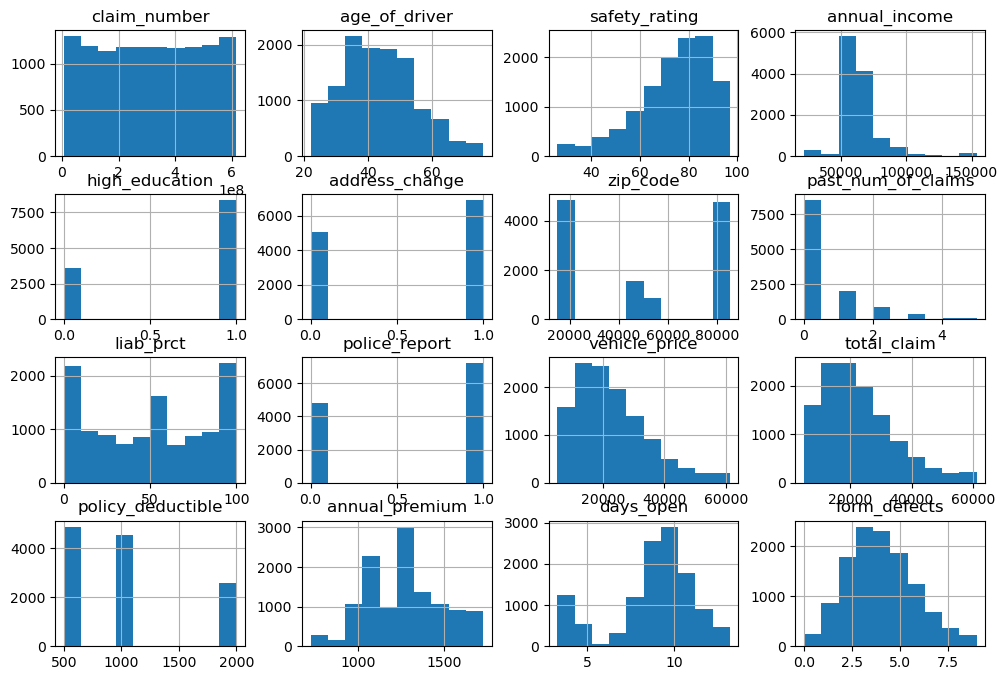

In [15]:
import matplotlib.pyplot as plt
df[num_cols].hist(figsize=(12,8)); plt.show()

In [16]:
df[cat_cols].nunique()

gender                   2
marital_status           3
property_status          2
claim_day_of_week        8
accident_site            3
witness_present          3
channel                  3
age_of_vehicle          16
vehicle_category         3
vehicle_color            7
injury_claim         11989
fraud_reported           2
dtype: int64

In [17]:
df.duplicated().sum()

0

In [18]:
df = df.drop_duplicates()

In [19]:
df[num_cols].corr()

,claim_number,age_of_driver,safety_rating,annual_income,high_education,address_change,zip_code,past_num_of_claims,liab_prct,police_report,vehicle_price,total_claim,policy_deductible,annual_premium,days_open,form_defects
claim_number,1.000000,-0.006829,-0.013443,-0.084192,-0.001035,-0.006029,-0.001027,0.017486,0.008288,-0.008401,-0.004805,-0.018910,-0.032431,0.055212,-0.002864,-0.012604
age_of_driver,-0.006829,1.000000,0.003329,0.231403,0.001072,0.009925,0.010325,-0.011006,-0.004427,-0.011821,0.005182,-0.013273,0.019197,-0.007742,0.318695,0.003988
safety_rating,-0.013443,0.003329,1.000000,-0.006698,-0.006810,0.007079,0.012440,-0.000054,0.010264,0.002992,-0.018529,-0.002421,-0.001447,-0.001511,0.010314,-0.010477
annual_income,-0.084192,0.231403,-0.006698,1.000000,-0.007917,-0.004082,-0.000991,0.008293,0.002611,0.002735,0.008079,0.001671,0.017193,-0.002881,0.080639,0.000649
high_education,-0.001035,0.001072,-0.006810,-0.007917,1.000000,-0.003850,-0.000605,0.014470,-0.003285,-0.001607,-0.002960,-0.001633,0.012754,-0.006341,0.006956,0.016197
address_change,-0.006029,0.009925,0.007079,-0.004082,-0.003850,1.000000,-0.015510,0.001581,0.000523,-0.005022,0.015696,0.004077,0.002275,0.003215,0.010527,-0.003880
zip_code,-0.001027,0.010325,0.012440,-0.000991,-0.000605,-0.015510,1.000000,-0.002053,-0.004939,0.008856,0.001433,-0.010421,-0.007682,0.004506,-0.005064,-0.008856
past_num_of_claims,0.017486,-0.011006,-0.000054,0.008293,0.014470,0.001581,-0.002053,1.000000,-0.024724,0.239659,0.009093,0.005854,-0.002559,-0.002884,-0.022609,0.014077
liab_prct,0.008288,-0.004427,0.010264,0.002611,-0.003285,0.000523,-0.004939,-0.024724,1.000000,-0.005962,-0.001894,0.010301,-0.012367,0.009177,-0.003383,-0.004154
police_report,-0.008401,-0.011821,0.002992,0.002735,-0.001607,-0.005022,0.008856,0.239659,-0.005962,1.000000,-0.007181,-0.007802,0.004347,0.005223,-0.001597,-0.000407


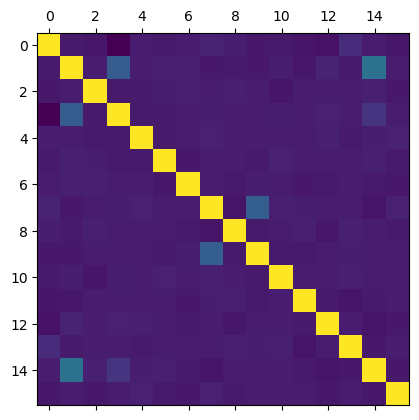

In [20]:
plt.matshow(df[num_cols].corr()); plt.show()

In [21]:
df[num_cols].skew()

claim_number         -0.009169
age_of_driver         0.413773
safety_rating        -0.914195
annual_income         2.484000
high_education       -0.863308
address_change       -0.310668
zip_code              0.016213
past_num_of_claims    2.370410
liab_prct             0.008471
police_report        -0.412838
vehicle_price         0.951142
total_claim           0.964538
policy_deductible     0.862164
annual_premium        0.242649
days_open            -0.837941
form_defects          0.363357
dtype: float64

In [22]:

import re
if 'age_of_vehicle' in df.columns:
    df['age_of_vehicle'] = df['age_of_vehicle'].astype(str).str.extract('(\d+)').astype(float)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\charm\AppData\Local\Temp\ipykernel_11300\423853263.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['age_of_vehicle'] = df['age_of_vehicle'].astype(str).str.extract('(\d+)').astype(float)


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12002 entries, 0 to 12001
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   claim_number        12002 non-null  float64       
 1   age_of_driver       12002 non-null  float64       
 2   gender              12002 non-null  object        
 3   marital_status      12002 non-null  object        
 4   safety_rating       12002 non-null  int64         
 5   annual_income       12002 non-null  float64       
 6   high_education      12002 non-null  int64         
 7   address_change      12002 non-null  int64         
 8   property_status     12002 non-null  object        
 9   zip_code            12002 non-null  int64         
 10  claim_date          11988 non-null  datetime64[ns]
 11  claim_day_of_week   12002 non-null  object        
 12  accident_site       12002 non-null  object        
 13  past_num_of_claims  12002 non-null  int64     

In [24]:
df.head()

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy_deductible,annual_premium,days_open,form_defects,fraud_reported
0,6511726.08,39.0,M,1,73,58612.8,1,0,Own,50048,...,Large,24360.59273,silver,26633.27819,5196.552552,1000,1406.91,8.641800,5,N
1,6511726.08,33.0,M,1,72,35936.0,0,1,Own,50006,...,Medium,23457.35282,black,26707.46021,7957.267641,2000,1415.74,10.009761,5,Y
2,6511726.08,31.0,M,1,76,84940.8,1,1,Own,15021,...,Medium,19752.42523,gray,15279.38583,3014.110884,1000,1199.44,8.264032,3,N
3,6511726.08,53.0,F,1,93,73526.4,0,1,Own,85027,...,Medium,32910.34224,red,20909.27772,5671.599025,500,722.66,9.235943,4,N
4,6511726.08,41.0,M,1,87,59403.2,1,0,Own,80046,...,Medium,28570.37675,red,34493.97997,4064.569489,1000,1187.96,10.259629,2,N


In [ ]:
#df.to_csv('../data/cleaned_no_encoding.csv', index=False)

In [25]:
df.shape

(12002, 29)

In [26]:
df['claim_number'] = df['claim_number'].astype(int)


In [27]:
df['vehicle_price'] = df['vehicle_price'].round(2)
df['total_claim'] = df['total_claim'].round(2)
df['injury_claim'] = df['injury_claim'].round(2)


In [28]:
df['days_open'] = df['days_open'].round(0).astype(int)


In [29]:
df['fraud_reported'] = df['fraud_reported'].map({'N': 0, 'Y': 1})


In [30]:
df.head()

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy_deductible,annual_premium,days_open,form_defects,fraud_reported
0,6511726,39.0,M,1,73,58612.8,1,0,Own,50048,...,Large,24360.59,silver,26633.28,5196.552552,1000,1406.91,9,5,0
1,6511726,33.0,M,1,72,35936.0,0,1,Own,50006,...,Medium,23457.35,black,26707.46,7957.267641,2000,1415.74,10,5,1
2,6511726,31.0,M,1,76,84940.8,1,1,Own,15021,...,Medium,19752.43,gray,15279.39,3014.110884,1000,1199.44,8,3,0
3,6511726,53.0,F,1,93,73526.4,0,1,Own,85027,...,Medium,32910.34,red,20909.28,5671.599025,500,722.66,9,4,0
4,6511726,41.0,M,1,87,59403.2,1,0,Own,80046,...,Medium,28570.38,red,34493.98,4064.569489,1000,1187.96,10,2,0


In [31]:
df

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy_deductible,annual_premium,days_open,form_defects,fraud_reported
0,6511726,39.0,M,1,73,58612.8,1,0,Own,50048,...,Large,24360.59,silver,26633.28,5196.552552,1000,1406.91,9,5,0
1,6511726,33.0,M,1,72,35936.0,0,1,Own,50006,...,Medium,23457.35,black,26707.46,7957.267641,2000,1415.74,10,5,1
2,6511726,31.0,M,1,76,84940.8,1,1,Own,15021,...,Medium,19752.43,gray,15279.39,3014.110884,1000,1199.44,8,3,0
3,6511726,53.0,F,1,93,73526.4,0,1,Own,85027,...,Medium,32910.34,red,20909.28,5671.599025,500,722.66,9,4,0
4,6511726,41.0,M,1,87,59403.2,1,0,Own,80046,...,Medium,28570.38,red,34493.98,4064.569489,1000,1187.96,10,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11997,616149089,34.0,M,1,88,66505.6,1,1,Rent,20134,...,Large,24134.33,red,34516.53,6639.049156,1000,1622.67,12,3,0
11998,616149089,65.0,F,1,97,23315.2,1,0,Rent,20134,...,Compact,57417.74,gray,26718.21,3382.4126,500,1055.60,10,6,1
11999,616149089,64.0,F,1,87,66505.6,0,1,Own,20142,...,Large,20231.72,other,27015.88,7475.901535,2000,1155.97,8,2,0
12000,616149089,34.0,F,1,70,76409.6,1,0,Own,20109,...,Compact,21900.03,black,16122.92,3838.951645,1000,1726.91,10,5,0


In [32]:
df.dtypes

claim_number                   int32
age_of_driver                float64
gender                        object
marital_status                object
safety_rating                  int64
annual_income                float64
high_education                 int64
address_change                 int64
property_status               object
zip_code                       int64
claim_date            datetime64[ns]
claim_day_of_week             object
accident_site                 object
past_num_of_claims             int64
witness_present               object
liab_prct                      int64
channel                       object
police_report                  int64
age_of_vehicle               float64
vehicle_category              object
vehicle_price                float64
vehicle_color                 object
total_claim                  float64
injury_claim                  object
policy_deductible              int64
annual_premium               float64
days_open                      int32
f

In [33]:
df['injury_claim'] = pd.to_numeric(df['injury_claim'], errors='coerce')

df['injury_claim'] = df['injury_claim'].fillna(0).astype(float)
df


,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy_deductible,annual_premium,days_open,form_defects,fraud_reported
0,6511726,39.0,M,1,73,58612.8,1,0,Own,50048,...,Large,24360.59,silver,26633.28,5196.552552,1000,1406.91,9,5,0
1,6511726,33.0,M,1,72,35936.0,0,1,Own,50006,...,Medium,23457.35,black,26707.46,7957.267641,2000,1415.74,10,5,1
2,6511726,31.0,M,1,76,84940.8,1,1,Own,15021,...,Medium,19752.43,gray,15279.39,3014.110884,1000,1199.44,8,3,0
3,6511726,53.0,F,1,93,73526.4,0,1,Own,85027,...,Medium,32910.34,red,20909.28,5671.599025,500,722.66,9,4,0
4,6511726,41.0,M,1,87,59403.2,1,0,Own,80046,...,Medium,28570.38,red,34493.98,4064.569489,1000,1187.96,10,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11997,616149089,34.0,M,1,88,66505.6,1,1,Rent,20134,...,Large,24134.33,red,34516.53,6639.049156,1000,1622.67,12,3,0
11998,616149089,65.0,F,1,97,23315.2,1,0,Rent,20134,...,Compact,57417.74,gray,26718.21,3382.412600,500,1055.60,10,6,1
11999,616149089,64.0,F,1,87,66505.6,0,1,Own,20142,...,Large,20231.72,other,27015.88,7475.901535,2000,1155.97,8,2,0
12000,616149089,34.0,F,1,70,76409.6,1,0,Own,20109,...,Compact,21900.03,black,16122.92,3838.951645,1000,1726.91,10,5,0


In [34]:
df['age_of_driver'] = pd.to_numeric(df['age_of_driver'], errors='coerce')

df['age_of_driver'] = df['age_of_driver'].fillna(0).astype(int)
df


,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy_deductible,annual_premium,days_open,form_defects,fraud_reported
0,6511726,39,M,1,73,58612.8,1,0,Own,50048,...,Large,24360.59,silver,26633.28,5196.552552,1000,1406.91,9,5,0
1,6511726,33,M,1,72,35936.0,0,1,Own,50006,...,Medium,23457.35,black,26707.46,7957.267641,2000,1415.74,10,5,1
2,6511726,31,M,1,76,84940.8,1,1,Own,15021,...,Medium,19752.43,gray,15279.39,3014.110884,1000,1199.44,8,3,0
3,6511726,53,F,1,93,73526.4,0,1,Own,85027,...,Medium,32910.34,red,20909.28,5671.599025,500,722.66,9,4,0
4,6511726,41,M,1,87,59403.2,1,0,Own,80046,...,Medium,28570.38,red,34493.98,4064.569489,1000,1187.96,10,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11997,616149089,34,M,1,88,66505.6,1,1,Rent,20134,...,Large,24134.33,red,34516.53,6639.049156,1000,1622.67,12,3,0
11998,616149089,65,F,1,97,23315.2,1,0,Rent,20134,...,Compact,57417.74,gray,26718.21,3382.412600,500,1055.60,10,6,1
11999,616149089,64,F,1,87,66505.6,0,1,Own,20142,...,Large,20231.72,other,27015.88,7475.901535,2000,1155.97,8,2,0
12000,616149089,34,F,1,70,76409.6,1,0,Own,20109,...,Compact,21900.03,black,16122.92,3838.951645,1000,1726.91,10,5,0


In [35]:
df.dtypes

claim_number                   int32
age_of_driver                  int32
gender                        object
marital_status                object
safety_rating                  int64
annual_income                float64
high_education                 int64
address_change                 int64
property_status               object
zip_code                       int64
claim_date            datetime64[ns]
claim_day_of_week             object
accident_site                 object
past_num_of_claims             int64
witness_present               object
liab_prct                      int64
channel                       object
police_report                  int64
age_of_vehicle               float64
vehicle_category              object
vehicle_price                float64
vehicle_color                 object
total_claim                  float64
injury_claim                 float64
policy_deductible              int64
annual_premium               float64
days_open                      int32
f

In [36]:
df['zip_code'] = df['zip_code'].astype(str)

df['injury_claim'] = pd.to_numeric(df['injury_claim'], errors='coerce').fillna(0)

df['total_claim'] = pd.to_numeric(df['total_claim'], errors='coerce').fillna(0)

df

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy_deductible,annual_premium,days_open,form_defects,fraud_reported
0,6511726,39,M,1,73,58612.8,1,0,Own,50048,...,Large,24360.59,silver,26633.28,5196.552552,1000,1406.91,9,5,0
1,6511726,33,M,1,72,35936.0,0,1,Own,50006,...,Medium,23457.35,black,26707.46,7957.267641,2000,1415.74,10,5,1
2,6511726,31,M,1,76,84940.8,1,1,Own,15021,...,Medium,19752.43,gray,15279.39,3014.110884,1000,1199.44,8,3,0
3,6511726,53,F,1,93,73526.4,0,1,Own,85027,...,Medium,32910.34,red,20909.28,5671.599025,500,722.66,9,4,0
4,6511726,41,M,1,87,59403.2,1,0,Own,80046,...,Medium,28570.38,red,34493.98,4064.569489,1000,1187.96,10,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11997,616149089,34,M,1,88,66505.6,1,1,Rent,20134,...,Large,24134.33,red,34516.53,6639.049156,1000,1622.67,12,3,0
11998,616149089,65,F,1,97,23315.2,1,0,Rent,20134,...,Compact,57417.74,gray,26718.21,3382.412600,500,1055.60,10,6,1
11999,616149089,64,F,1,87,66505.6,0,1,Own,20142,...,Large,20231.72,other,27015.88,7475.901535,2000,1155.97,8,2,0
12000,616149089,34,F,1,70,76409.6,1,0,Own,20109,...,Compact,21900.03,black,16122.92,3838.951645,1000,1726.91,10,5,0


In [37]:
df.dtypes

claim_number                   int32
age_of_driver                  int32
gender                        object
marital_status                object
safety_rating                  int64
annual_income                float64
high_education                 int64
address_change                 int64
property_status               object
zip_code                      object
claim_date            datetime64[ns]
claim_day_of_week             object
accident_site                 object
past_num_of_claims             int64
witness_present               object
liab_prct                      int64
channel                       object
police_report                  int64
age_of_vehicle               float64
vehicle_category              object
vehicle_price                float64
vehicle_color                 object
total_claim                  float64
injury_claim                 float64
policy_deductible              int64
annual_premium               float64
days_open                      int32
f

In [38]:
df.isnull().sum()

claim_number           0
age_of_driver          0
gender                 0
marital_status         0
safety_rating          0
annual_income          0
high_education         0
address_change         0
property_status        0
zip_code               0
claim_date            14
claim_day_of_week      0
accident_site          0
past_num_of_claims     0
witness_present        0
liab_prct              0
channel                0
police_report          0
age_of_vehicle         3
vehicle_category       0
vehicle_price          0
vehicle_color          0
total_claim            0
injury_claim           0
policy_deductible      0
annual_premium         0
days_open              0
form_defects           0
fraud_reported         0
dtype: int64

In [39]:
df['claim_date'] = pd.to_datetime(df['claim_date'], errors='coerce')
df['claim_date'] = df['claim_date'].fillna(df['claim_date'].mode()[0])


In [40]:
df['age_of_vehicle'] = df['age_of_vehicle'].fillna(df['age_of_vehicle'].median())


In [41]:
df.isnull().sum()

claim_number          0
age_of_driver         0
gender                0
marital_status        0
safety_rating         0
annual_income         0
high_education        0
address_change        0
property_status       0
zip_code              0
claim_date            0
claim_day_of_week     0
accident_site         0
past_num_of_claims    0
witness_present       0
liab_prct             0
channel               0
police_report         0
age_of_vehicle        0
vehicle_category      0
vehicle_price         0
vehicle_color         0
total_claim           0
injury_claim          0
policy_deductible     0
annual_premium        0
days_open             0
form_defects          0
fraud_reported        0
dtype: int64

In [42]:
df.to_csv('../data/pre_processed_data.csv', index=False)


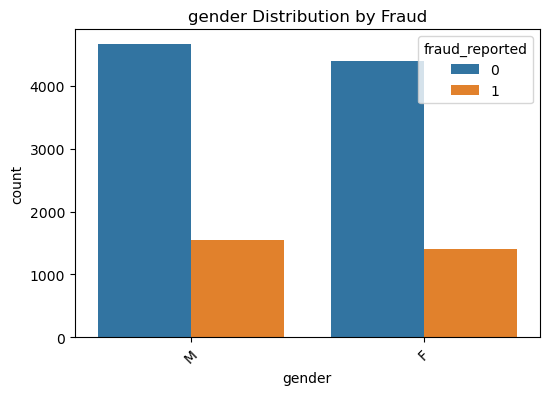

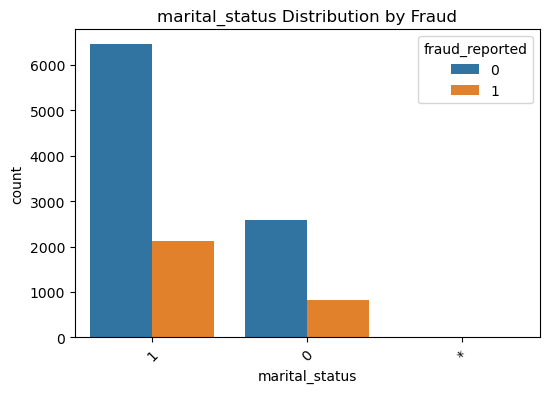

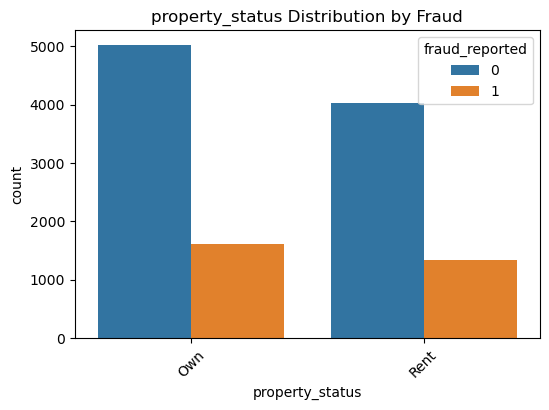

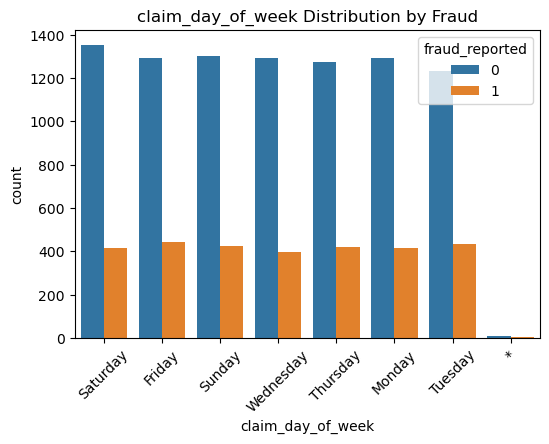

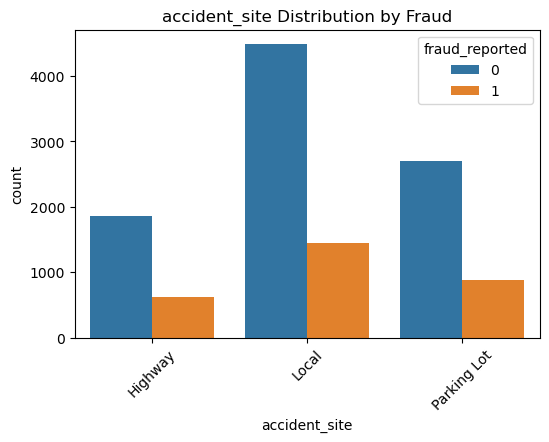

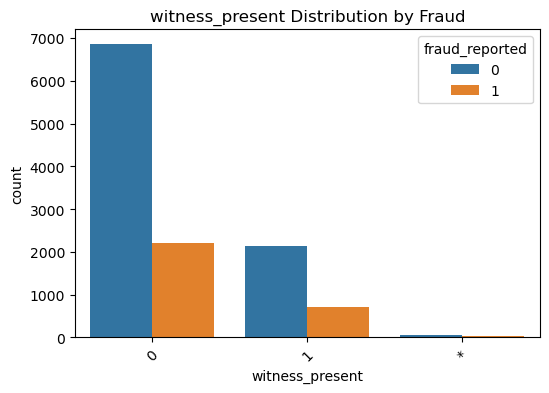

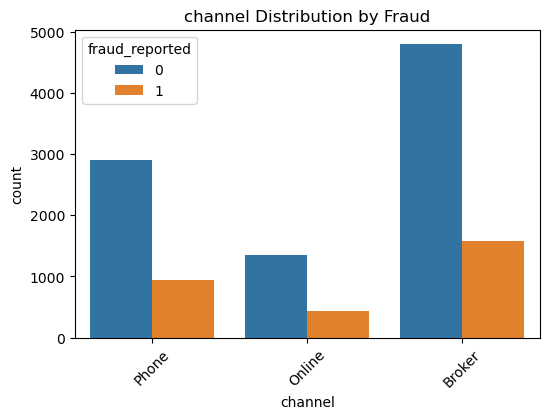

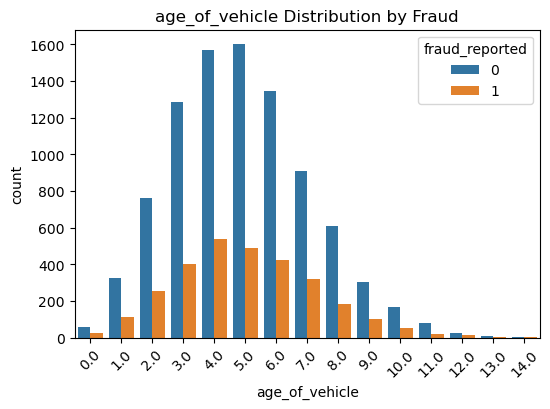

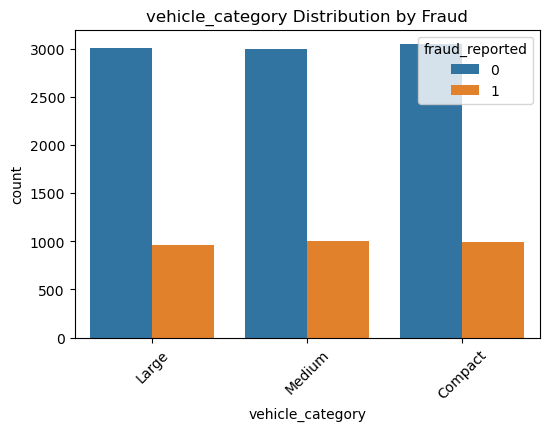

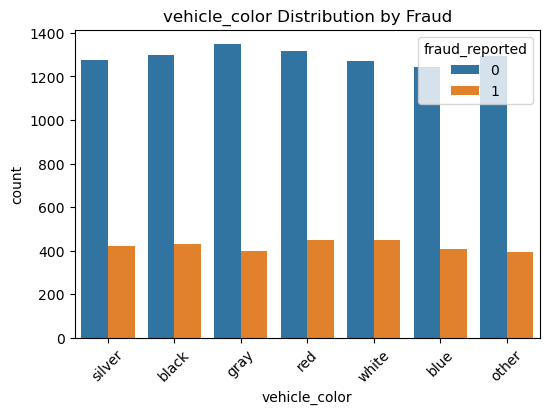

c:\Users\charm\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


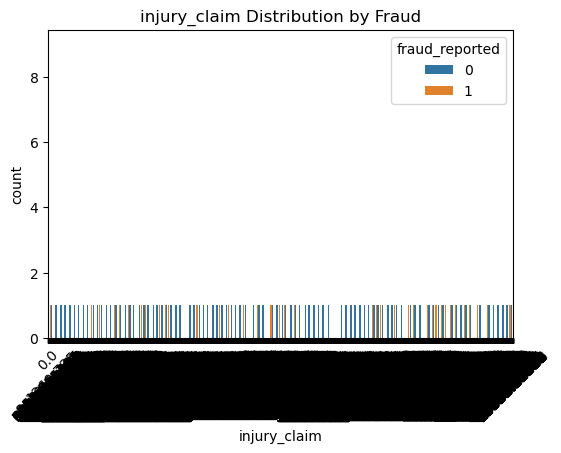

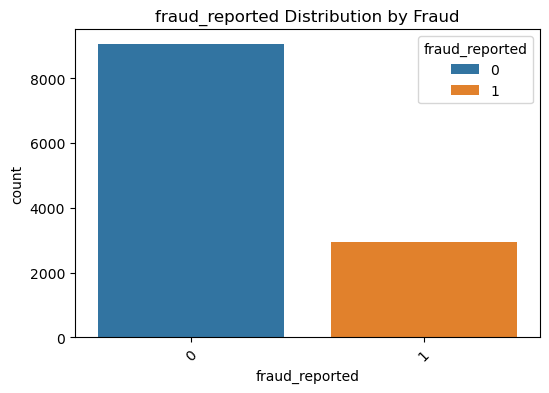

In [43]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='fraud_reported', data=df)
    plt.title(f'{col} Distribution by Fraud')
    plt.xticks(rotation=45)
    plt.show()